# Load Python Modules

In [1]:
#Arbritary Wave Generator

from rigol_dg922_pro import RigolDG922

RESOURCE = "USB0::0x1AB1::0x0646::DG9R280300043::INSTR"  # update if your VISA address differs
gen = RigolDG922(RESOURCE)  # auto_open=True by default
print("Connected to:", gen.idn)

#Moku:Lab Phasometer

from phasemeter_client_v2_new import PhasemeterClient

# Fill in the target of your Moku (e.g., '192.168.1.100' or link-local IPv6)
TARGET = '[fe80::7269:79ff:feb7:d15%6]'  # <-- replace if needed
client = PhasemeterClient(target=TARGET, acquisition_speed='119Hz')
client.load(f0_hz=1e6)  # optional initial lock

#Thorlabs TLX5 Laser

import TLX_5
laser=TLX_5.TRL_5()
port="COM4"
laser.connect(port)
def laser_ON_OFF(my_key=str):
    if my_key=="ON":
        laser.laser_ON()
    else:
        laser.laser_OFF()
        
#Other Python Modules
import numpy as np
import time
import os
import matplotlib.pyplot as plt
import pandas as pd

Connected to: RIGOL TECHNOLOGIES,DG922 Pro,DG9R280300043,00.02.01.00.02


# Settings

## AWG

In [2]:
#Sin wave frequency
freq=int(10e6)

#MZM Vpi Voltage (setting @80%)
Vpi=5
coeff=1

#Setting Vpp
Vpp_Ch1=round(Vpi*coeff,3)
#Set waveform on CH1
gen.set_waveform(ch=1, wave="SIN", freq_hz=freq, ampl_vpp=Vpp_Ch1, offset_v=0.0)
#Set phase of CH1
gen.set_phase_deg(ch=1, phase_deg=0) 

#Set ch1 impedance to 50 Ohms or INF
gen.set_load(ch=1, load='50')


## Moku:Lab Phasometer

In [3]:
# Change front-end input range for channel 1, then both
client.set_frontend(1, input_range='1Vpp')
client.set_frontend(2, input_range='1Vpp')

# Change PLL bandwidth for both channels
client.set_bandwidth_all('100Hz')

# Move center frequency (both channels track the same f)
client.set_frequency_all(freq)

## TLX5 Laser wavelength

In [4]:
#Setting Laser Wavelength in (nm)
wl="1550"
laser.change_WL(wl)  # in nm
laser.laser_current_wavelength()
#Switching Laser ON  or OFF
my_key="OFF"
laser_ON_OFF(my_key)

Laser Wavelength=1550.0 nm


# Measurements

## Reading phase difference single sample

In [6]:
#Turn AWG Ch1 ouput ON
gen.output_on(1)
laser_ON_OFF("ON")
#Settle time
time.sleep(3)

#Reset phase unwrap
client.reset_unwrap()

#Get Phase Difference and Frequencies from Phasometer
dphi_deg, frame=client.read_delta_phi_deg(mode='unwrapped')
print('Δφ [deg]:', dphi_deg)
print('f1 [Hz]:', frame['ch1']['frequency'], 'f2 [Hz]:', frame['ch2']['frequency'])

#Turn AWG Ch1 ouput OFF
gen.output_off(1)

Δφ [deg]: 85.99631488323212
f1 [Hz]: 9999980.119973272 f2 [Hz]: 9999980.122742614


## Frequency Sweeps

In [7]:
#Sweep Parameters
#Set Frequency range for the sweep
freqs=np.linspace(10e6,100e6,91)
#Number of measuremens per point ()
N=20
#Settle times for AWG
t_s=2

### Calibration

Use only FBS

In [8]:
#Calibration

#AWG Loop
def freq_generator():
    for f in freqs:
        gen.set_waveform(ch=1, wave="SIN", freq_hz=int(f), ampl_vpp=Vpp_Ch1, offset_v=0.0)
        yield float(f)

#reset Phase unwrap
client.reset_unwrap()

#AWG ON
gen.output_on(1)

#Phasometer Sweep 
calib = client.sweep_phase_vs_frequency_external(
    freq_generator(),
    settle_s=t_s,
    samples_per_point=N,
    mode="both",                 # wrapped/unwrapped/raw all recorded
    set_pll_to_frequency=True,   # recommended: keep PLL centered on AWG freq
    reacquire_each_step=True,
    reset_unwrap=False
)

#AWG OFF
gen.output_off(1)

#Save callibration data
client.save_rows_to_csv(calib, "calib.csv")

'c:\\Users\\Experiment\\Documents\\Python\\VQ_Instruments\\calib.csv'

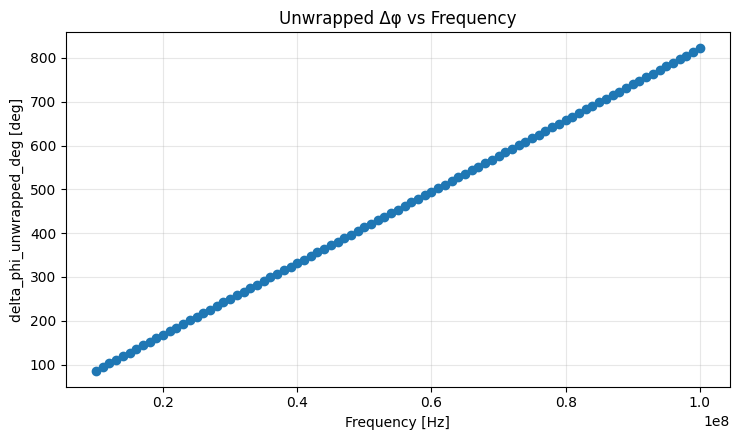

In [9]:
## Plot Frequency sweep
client.plot_sweep(calib, y_key="delta_phi_unwrapped_deg", title="Unwrapped Δφ vs Frequency")

### FUT measurements

In [10]:
#FUT

#AWG Loop
def freq_generator():
    for f in freqs:
        gen.set_waveform(ch=1, wave="SIN", freq_hz=int(f), ampl_vpp=Vpp_Ch1, offset_v=0.0)
        yield float(f)

#reset Phase unwrap
client.reset_unwrap()

#AWG ON
gen.output_on(1)

#Phasometer Sweep 
fut = client.sweep_phase_vs_frequency_external(
    freq_generator(),
    settle_s=t_s,
    samples_per_point=N,
    mode="both",                 # wrapped/unwrapped/raw all recorded
    set_pll_to_frequency=True,   # recommended: keep PLL centered on AWG freq
    reacquire_each_step=True,
    reset_unwrap=False
)

#AWG OFF
gen.output_off(1)

#Save callibration data
client.save_rows_to_csv(fut, "fut.csv")

'c:\\Users\\Experiment\\Documents\\Python\\VQ_Instruments\\fut.csv'

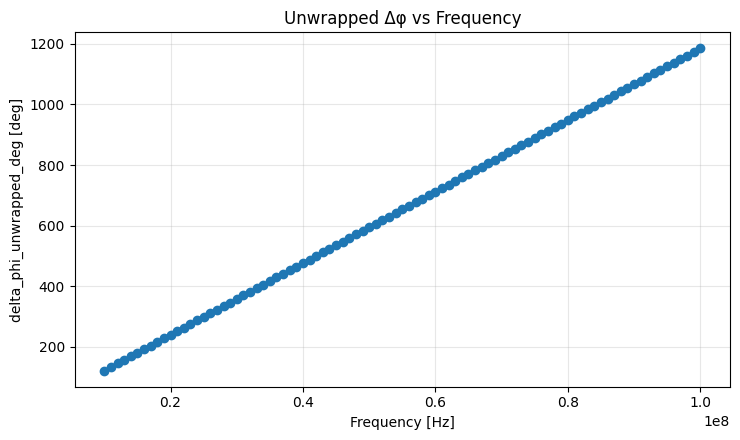

In [11]:
## Plot Frequency sweep
client.plot_sweep(fut, y_key="delta_phi_unwrapped_deg", title="Unwrapped Δφ vs Frequency")

# Fitting frequency vs phase difference

In [12]:
#Load Fitting (linear)
import pandas as pd


def unwrap_degrees(phi_deg):
    """
    Unwrap a phase series given in degrees.
    Uses numpy.unwrap in radians then converts back.
    """
    phi_rad = np.deg2rad(phi_deg.to_numpy(dtype=float))
    unwrapped_rad = np.unwrap(phi_rad)
    return np.rad2deg(unwrapped_rad)

def fit_line_frequency_phase(
    csv_path,
    freq_col="frequency_hz",
    phase_col=None,
    unwrap=False,
    dropna=True,
    robust=False,
    plot=True,
    title=None,
):
    """
    Fit phase difference vs frequency with a straight line and return slope/intercept.

    Parameters
    ----------
    csv_path : str
        Path to CSV file.
    freq_col : str
        Column name for frequency in Hz.
    phase_col : str or None
        Column name for phase difference in degrees.
        If None, will auto-select among common names.
    unwrap : bool
        If True, unwrap phase (useful if phase wraps around +/-180 or 360).
    robust : bool
        If True, uses a simple robust fit by iteratively removing outliers (MAD-based).
    plot : bool
        If True, plot data, fit, and residuals.

    Returns
    -------
    results : dict
        slope_deg_per_hz, intercept_deg, slope_deg_per_mhz, r2, n_points, df_used
    """

    # ---- Load ----
    df = pd.read_csv(csv_path, comment="#")  # allow metadata lines starting with '#'

    # ---- Choose phase column automatically if not provided ----
    if phase_col is None:
        candidates = [
            "delta_phi_unwrapped_deg",
            "delta_phi_deg",
            "delta_phi_wrapped_deg",
            "phase_deg",
        ]
        found = [c for c in candidates if c in df.columns]
        if not found:
            raise ValueError(
                f"Could not find a phase column. Available columns: {list(df.columns)}.\n"
                f"Pass phase_col explicitly."
            )
        phase_col = found[0]
        print(f"[info] Using phase column: {phase_col}")

    # ---- Clean ----
    use_cols = [freq_col, phase_col]
    d = df[use_cols].copy()

    # Convert to numeric (handles accidental strings)
    d[freq_col] = pd.to_numeric(d[freq_col], errors="coerce")
    d[phase_col] = pd.to_numeric(d[phase_col], errors="coerce")
    if dropna:
        d = d.dropna()

    if len(d) < 2:
        raise ValueError("Not enough valid points to fit a line (need at least 2).")

    # Sort by frequency (important for unwrapping)
    d = d.sort_values(freq_col).reset_index(drop=True)

    # ---- Optional unwrap ----
    if unwrap:
        d[phase_col] = unwrap_degrees(d[phase_col])

    # ---- Fit helper ----
    def do_fit(x, y):
        # polyfit returns [m, b] for degree=1
        m, b = np.polyfit(x, y, 1)
        yhat = m*x + b
        # R^2
        ss_res = np.sum((y - yhat)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        return m, b, yhat, r2

    x = d[freq_col].to_numpy(dtype=float)
    y = d[phase_col].to_numpy(dtype=float)

    # ---- Optional robust fit (MAD outlier rejection) ----
    if robust and len(d) >= 10:
        mask = np.ones_like(y, dtype=bool)
        for _ in range(5):  # a few iterations
            m, b, yhat, r2 = do_fit(x[mask], y[mask])
            resid = y - (m*x + b)
            # MAD-based threshold
            med = np.median(resid[mask])
            mad = np.median(np.abs(resid[mask] - med)) + 1e-12
            z = 0.6745 * (resid - med) / mad
            new_mask = np.abs(z) < 3.5
            # stop if stable
            if new_mask.sum() == mask.sum():
                break
            mask = new_mask
        # final fit
        x_fit = x[mask]
        y_fit = y[mask]
        m, b, yhat_fit, r2 = do_fit(x_fit, y_fit)
        # for plotting full-series predicted line on full x:
        yhat_all = m*x + b
        used = d.loc[mask].copy()
    else:
        m, b, yhat_all, r2 = do_fit(x, y)
        used = d.copy()
        mask = np.ones_like(y, dtype=bool)

    slope_deg_per_hz = m
    slope_deg_per_mhz = m * 1e6

    results = {
        "slope_deg_per_hz": slope_deg_per_hz,
        "slope_deg_per_mhz": slope_deg_per_mhz,
        "intercept_deg": b,
        "r2": r2,
        "n_points": int(mask.sum()),
        "phase_col": phase_col,
        "freq_col": freq_col,
        "df_used": used,
    }

    # ---- Print summary ----
    print("\n=== Linear Fit: Δφ(f) = m f + b ===")
    print(f"m (inclination) = {slope_deg_per_hz:.6e} deg/Hz  = {slope_deg_per_mhz:.6f} deg/MHz")
    print(f"b (intercept)   = {b:.6f} deg")
    print(f"R²              = {r2:.6f}")
    print(f"Points used     = {int(mask.sum())} / {len(d)}")
    if unwrap:
        print("[info] Phase was unwrapped before fitting.")
    if robust:
        print("[info] Robust mode enabled (MAD outlier rejection).")

    # ---- Plot ----
    if plot:
        if title is None:
            title = f"Phase difference vs frequency (fit on {phase_col})"

        fig, axes = plt.subplots(2, 1, figsize=(8.5, 7), sharex=True)
        ax = axes[0]
        ax.scatter(x, y, s=18, alpha=0.7, label="data")
        if robust and (mask.sum() != len(mask)):
            ax.scatter(x[~mask], y[~mask], s=30, alpha=0.7, label="excluded", marker="x")

        ax.plot(x, yhat_all, color="tab:red", lw=2, label="linear fit")
        ax.set_ylabel("Δφ [deg]")
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend()

        ax2 = axes[1]
        resid = y - yhat_all
        ax2.axhline(0, color="k", lw=1)
        ax2.scatter(x, resid, s=18, alpha=0.7)
        ax2.set_xlabel("Frequency [Hz]")
        ax2.set_ylabel("Residual [deg]")
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return results


# ---------------- Example call ----------------
# results = fit_line_frequency_phase(
#     "phase_vs_frequency.csv",
#     freq_col="frequency_hz",
#     phase_col=None,      # auto
#     unwrap=False,        # set True if your phase wraps
#     robust=False,        # set True if you expect outliers
#     plot=True
# )

In [13]:
#Running linear fit on calibration points
results_calib = fit_line_frequency_phase(
    "calib.csv",
    phase_col="delta_phi_unwrapped_deg",
    unwrap=True,   # already unwrapped
    plot=False
)


=== Linear Fit: Δφ(f) = m f + b ===
m (inclination) = 8.167975e-06 deg/Hz  = 8.167975 deg/MHz
b (intercept)   = 4.610071 deg
R²              = 0.999999
Points used     = 91 / 91
[info] Phase was unwrapped before fitting.


In [14]:
#Running linear fit on FUT
results_fut = fit_line_frequency_phase(
    "fut.csv",
    phase_col="delta_phi_unwrapped_deg",
    unwrap=False,   # already unwrapped
    plot=False
)


=== Linear Fit: Δφ(f) = m f + b ===
m (inclination) = 1.181235e-05 deg/Hz  = 11.812350 deg/MHz
b (intercept)   = 3.414129 deg
R²              = 1.000000
Points used     = 91 / 91


## Fibre Length Calculation (No Callibration)

In [15]:
#Fibre Length Calculation

def fibre_length_and_error(
    slope_deg_per_hz,
    slope_std_deg_per_hz,
    ng=1.468,
    ng_std=0.001,
):
    """
    Compute fibre length and uncertainty from phase slope.

    Returns:
      L_m        : fibre length (m)
      sigma_L_m  : total uncertainty (m)
      components : dict with individual error terms
    """
    c = 299_792_458.0

    # Length
    if slope_deg_per_hz<0:
        L = -c * slope_deg_per_hz / (360.0 * ng)
    else:
        L = c * slope_deg_per_hz / (360.0 * ng)

    # Error from slope
    sigma_L_m = c * slope_std_deg_per_hz / (360.0 * ng)

    # Error from refractive index
    sigma_L_ng = abs(L) * (ng_std / ng)

    # Total error
    sigma_L = np.sqrt(sigma_L_m**2 + sigma_L_ng**2)

    return L, sigma_L, {
        "sigma_from_slope_m": sigma_L_m,
        "sigma_from_ng_m": sigma_L_ng,
    }

In [16]:

# Fibre Length
slope = results_fut['slope_deg_per_hz']       # deg/Hz
slope_std = 2.0e-9      # deg/Hz (from fit covariance)

L, dL, parts = fibre_length_and_error(slope, slope_std)

print(f"Fibre length = {L:.3f} m")
print(f"Uncertainty  = ±{dL:.3f} m")
print(parts)


Fibre length = 6.701 m
Uncertainty  = ±0.005 m
{'sigma_from_slope_m': 0.0011345460868907055, 'sigma_from_ng_m': np.float64(0.004564596549276052)}


## Fibre Length with callibration

In [17]:

def fibre_length_from_calibration(
    slope_meas_deg_per_hz,
    slope_cal_deg_per_hz,
    slope_meas_std,
    slope_cal_std,
    ng=1.468,
    ng_std=0.001,
):
    """
    Compute fibre length and uncertainty using a calibration measurement.

    Parameters
    ----------
    slope_meas_deg_per_hz : float
        Fitted slope with fibre present
    slope_cal_deg_per_hz : float
        Fitted slope from calibration (no fibre)
    slope_meas_std : float
        Standard deviation (1σ) of slope_meas
    slope_cal_std : float
        Standard deviation (1σ) of slope_cal
    ng : float
        Group index (SMF-28 @ 1550 nm ≈ 1.468)
    ng_std : float
        Uncertainty in group index

    Returns
    -------
    L_m : float
        Fibre length in meters
    sigma_L_m : float
        Total uncertainty (meters)
    details : dict
        Error contributions
    """

    c = 299_792_458.0

    #Negative slope
    if slope_meas_deg_per_hz<0:
        slope_meas_deg_per_hz=-1*slope_meas_deg_per_hz
        
    if slope_cal_deg_per_hz<0:
        slope_cal_deg_per_hz=-1*slope_cal_deg_per_hz


    # Fibre-only slope
    m_fibre = slope_meas_deg_per_hz - slope_cal_deg_per_hz
    sigma_m = np.sqrt(slope_meas_std**2 + slope_cal_std**2)

    # Length
    L = c * m_fibre / (360.0 * ng)

    # Errors
    sigma_L_fit = c * sigma_m / (360.0 * ng)
    sigma_L_ng = abs(L) * (ng_std / ng)

    sigma_L = np.sqrt(sigma_L_fit**2 + sigma_L_ng**2)

    return L, sigma_L, {
        "fibre_slope_deg_per_hz": m_fibre,
        "sigma_from_fit_m": sigma_L_fit,
        "sigma_from_ng_m": sigma_L_ng,
    }

In [18]:

# Fiber Length
m_meas = results_fut['slope_deg_per_hz']    # deg/Hz (with fibre)
m_cal  = results_calib['slope_deg_per_hz']      # deg/Hz (calibration)
s_meas = 1.5e-9
s_cal  = 1.2e-9

L, dL, info = fibre_length_from_calibration(
    m_meas, m_cal, s_meas, s_cal
)

print(f"Fibre length = {L:.3f} m ± {dL:.3f} m")
print(info)


Fibre length = 2.067 m ± 0.002 m
{'fibre_slope_deg_per_hz': np.float64(3.644374966664114e-06), 'sigma_from_fit_m': np.float64(0.0010896959321181703), 'sigma_from_ng_m': np.float64(0.0014082804351468717)}


## Fibre Length with callibration -- Improved (Including error calculation)

In [ ]:

# -----------------------------
# Constants for SMF-28 @ 1550 nm
# -----------------------------
C = 299_792_458.0          # speed of light [m/s]
NG_DEFAULT = 1.468         # SMF-28 group index at 1550 nm (typical)
NG_STD_DEFAULT = 0.001     # typical uncertainty if not otherwise known


# -----------------------------
# Helpers
# -----------------------------
def unwrap_deg(phi_deg: np.ndarray) -> np.ndarray:
    """
    Unwrap phase given in degrees using numpy.unwrap in radians.
    """
    phi_rad = np.deg2rad(phi_deg.astype(float))
    phi_unwrapped = np.unwrap(phi_rad)
    return np.rad2deg(phi_unwrapped)


def load_xy_from_csv(
    csv_path: str,
    freq_col: str = "frequency_hz",
    phase_col: str | None = None,
) -> tuple[np.ndarray, np.ndarray, str]:
    """
    Load (frequency, phase) from a CSV file.
    Auto-selects a phase column if not specified.
    Supports metadata/comment lines starting with '#'.
    """
    df = pd.read_csv(csv_path, comment="#")

    if phase_col is None:
        # Try common names used in our earlier sweep outputs
        candidates = [
            "delta_phi_unwrapped_deg",
            "delta_phi_deg",
            "delta_phi_wrapped_deg",
            "delta_phi_raw_deg",
        ]
        found = [c for c in candidates if c in df.columns]
        if not found:
            raise ValueError(
                f"No phase column found. Available columns: {list(df.columns)}. "
                f"Please pass phase_col explicitly."
            )
        phase_col = found[0]

    x = pd.to_numeric(df[freq_col], errors="coerce").to_numpy()
    y = pd.to_numeric(df[phase_col], errors="coerce").to_numpy()
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    # Sort by frequency (important for unwrapping and interpretability)
    idx = np.argsort(x)
    return x[idx].astype(float), y[idx].astype(float), phase_col


def linear_fit_with_sigma_m(
    f_hz: np.ndarray,
    phi_deg: np.ndarray,
    unwrap: bool = False,
    plot: bool = True,
    title: str | None = None,
) -> dict:
    """
    Fit phi_deg = m * f_hz + b, and compute sigma_m from covariance.

    Uses numpy.polyfit(..., cov=True) which returns a covariance matrix of the
    coefficient estimates; std errors are sqrt(diagonal(cov)). [1](https://www.geeksforgeeks.org/data-analysis/numpys-polyfit-function-a-comprehensive-guide/)[2](https://stackoverflow.com/questions/27757732/find-uncertainty-from-polyfit)
    """
    f = np.asarray(f_hz, dtype=float)
    y = np.asarray(phi_deg, dtype=float)

    if unwrap:
        y = unwrap_deg(y)

    # Fit: y = m*f + b
    # polyfit returns coefficients highest power first: [m, b]
    (m, b), cov = np.polyfit(f, y, deg=1, cov=True)  # [1](https://www.geeksforgeeks.org/data-analysis/numpys-polyfit-function-a-comprehensive-guide/)[2](https://stackoverflow.com/questions/27757732/find-uncertainty-from-polyfit)

    sigma_m = float(np.sqrt(cov[0, 0]))  # std error of slope [1](https://www.geeksforgeeks.org/data-analysis/numpys-polyfit-function-a-comprehensive-guide/)[2](https://stackoverflow.com/questions/27757732/find-uncertainty-from-polyfit)
    sigma_b = float(np.sqrt(cov[1, 1]))  # std error of intercept [1](https://www.geeksforgeeks.org/data-analysis/numpys-polyfit-function-a-comprehensive-guide/)[2](https://stackoverflow.com/questions/27757732/find-uncertainty-from-polyfit)

    y_hat = m * f + b
    resid = y - y_hat

    # R^2 (goodness-of-fit)
    ss_res = float(np.sum(resid**2))
    ss_tot = float(np.sum((y - np.mean(y))**2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    if plot:
        if title is None:
            title = "Linear fit: phase difference vs frequency"
        fig, ax = plt.subplots(2, 1, figsize=(8.5, 7), sharex=True)

        ax[0].scatter(f, y, s=18, alpha=0.75, label="data")
        ax[0].plot(f, y_hat, lw=2, color="tab:red", label="fit")
        ax[0].set_ylabel("Δφ [deg]")
        ax[0].set_title(title)
        ax[0].grid(True, alpha=0.3)
        ax[0].legend()

        ax[1].axhline(0, color="k", lw=1)
        ax[1].scatter(f, resid, s=18, alpha=0.75)
        ax[1].set_xlabel("Frequency [Hz]")
        ax[1].set_ylabel("Residual [deg]")
        ax[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return {
        "m_deg_per_hz": float(m),
        "b_deg": float(b),
        "sigma_m_deg_per_hz": sigma_m,
        "sigma_b_deg": sigma_b,
        "r2": float(r2),
        "n": int(len(f)),
        "unwrap_applied": bool(unwrap),
    }


def slope_to_group_delay(m_deg_per_hz: float) -> float:
    """
    Convert slope (deg/Hz) to group delay tau [s].
    tau = -m / 360
    """
    return -m_deg_per_hz / 360.0


def slope_sigma_to_group_delay_sigma(sigma_m_deg_per_hz: float) -> float:
    """
    Propagate slope uncertainty to group delay uncertainty.
    sigma_tau = sigma_m / 360
    """
    return sigma_m_deg_per_hz / 360.0


def group_delay_to_length(tau_s: float, ng: float = NG_DEFAULT) -> float:
    """
    Convert group delay to fibre length: L = c * tau / ng
    """
    return (C * tau_s) / ng


def group_delay_sigma_to_length_sigma(sigma_tau_s: float, ng: float = NG_DEFAULT) -> float:
    """
    Convert group delay uncertainty to length uncertainty from the fit only:
    sigma_L_fit = c * sigma_tau / ng
    """
    return (C * sigma_tau_s) / ng


def length_uncertainty_from_ng(L_m: float, ng: float = NG_DEFAULT, ng_std: float = NG_STD_DEFAULT) -> float:
    """
    Uncertainty in length due to uncertainty in group index:
    sigma_L_ng = |L| * (ng_std / ng)
    """
    return abs(L_m) * (ng_std / ng)


def combine_uncertainties(*sigmas: float) -> float:
    """
    Quadrature sum of independent uncertainties.
    """
    return float(np.sqrt(np.sum(np.asarray(sigmas, dtype=float) ** 2)))


# -----------------------------
# Calibration workflow
# -----------------------------
def calibrated_length_from_two_fits(
    fit_meas: dict,
    fit_cal: dict,
    ng: float = NG_DEFAULT,
    ng_std: float = NG_STD_DEFAULT,
) -> dict:
    """
    Compute fibre-only slope = m_meas - m_cal,
    then convert to tau and length and propagate uncertainties.

    slope uncertainty adds in quadrature:
      sigma_m_fibre = sqrt(sigma_m_meas^2 + sigma_m_cal^2)

    total length uncertainty includes:
      - fit-related uncertainty
      - group index uncertainty (ng)
    """
    m_meas = fit_meas["m_deg_per_hz"]
    m_cal  = fit_cal["m_deg_per_hz"]
    sm_meas = fit_meas["sigma_m_deg_per_hz"]
    sm_cal  = fit_cal["sigma_m_deg_per_hz"]

    m_fibre = m_meas - m_cal
    sm_fibre = float(np.sqrt(sm_meas**2 + sm_cal**2))

    tau = slope_to_group_delay(m_fibre)
    stau = slope_sigma_to_group_delay_sigma(sm_fibre)

    L = group_delay_to_length(tau, ng=ng)
    sL_fit = group_delay_sigma_to_length_sigma(stau, ng=ng)
    sL_ng  = length_uncertainty_from_ng(L, ng=ng, ng_std=ng_std)
    sL_total = combine_uncertainties(sL_fit, sL_ng)

    return {
        "m_fibre_deg_per_hz": m_fibre,
        "sigma_m_fibre_deg_per_hz": sm_fibre,
        "tau_s": tau,
        "sigma_tau_s": stau,
        "L_m": L,
        "sigma_L_fit_m": sL_fit,
        "sigma_L_ng_m": sL_ng,
        "sigma_L_total_m": sL_total,
        "ng": ng,
        "ng_std": ng_std,
    }


# -----------------------------
# Main usage example
# -----------------------------
if __name__ == "__main__":
    # ---- USER INPUTS ----
    # Your measurement sweep CSV (with fibre under test)
    MEAS_CSV = "fut.csv"

    # Your calibration sweep CSV (same setup, no fibre OR reference)
    CAL_CSV  = "calib.csv"

    # Columns in your CSV
    FREQ_COL = "frequency_hz"

    # Choose which phase column to fit:
    # If you saved mode='both', you can use 'delta_phi_unwrapped_deg'
    # If you saved wrapped only, set UNWRAP=True and use wrapped column.
    PHASE_COL_MEAS = None   # auto-detect
    PHASE_COL_CAL  = None   # auto-detect

    # If your CSV uses wrapped phase, set True; if already unwrapped in CSV, set False
    UNWRAP = False

    # SMF-28 parameters at 1550 nm
    NG = 1.468
    NG_STD = 0.001

    # ---- LOAD DATA ----
    f_meas, phi_meas, phcol_meas = load_xy_from_csv(MEAS_CSV, freq_col=FREQ_COL, phase_col=PHASE_COL_MEAS)
    f_cal,  phi_cal,  phcol_cal  = load_xy_from_csv(CAL_CSV,  freq_col=FREQ_COL, phase_col=PHASE_COL_CAL)

    # ---- FIT (includes sigma_m) ----
    fit_meas = linear_fit_with_sigma_m(
        f_meas,
        phi_meas,
        unwrap=UNWRAP,
        plot=False,
        title=f"MEAS fit using {phcol_meas} (unwrap={UNWRAP})",
    )

    fit_cal = linear_fit_with_sigma_m(
        f_cal,
        phi_cal,
        unwrap=UNWRAP,
        plot=False,
        title=f"CAL fit using {phcol_cal} (unwrap={UNWRAP})",
    )

    # ---- CALIBRATED LENGTH ----
    out = calibrated_length_from_two_fits(fit_meas, fit_cal, ng=NG, ng_std=NG_STD)

    # ---- PRINT RESULTS ----
    print("\n==============================")
    print("Fit results (MEAS):")
    print(f"  m = {fit_meas['m_deg_per_hz']:.6e} ± {fit_meas['sigma_m_deg_per_hz']:.3e} deg/Hz")
    print(f"  R^2 = {fit_meas['r2']:.6f}, N = {fit_meas['n']}")

    print("\nFit results (CAL):")
    print(f"  m = {fit_cal['m_deg_per_hz']:.6e} ± {fit_cal['sigma_m_deg_per_hz']:.3e} deg/Hz")
    print(f"  R^2 = {fit_cal['r2']:.6f}, N = {fit_cal['n']}")

    print("\n==============================")
    print("Calibrated (MEAS - CAL):")
    print(f"  m_fibre = {out['m_fibre_deg_per_hz']:.6e} ± {out['sigma_m_fibre_deg_per_hz']:.3e} deg/Hz")

    print("\nGroup delay:")
    print(f"  tau = {out['tau_s']:.6e} ± {out['sigma_tau_s']:.3e} s")
    print(f"        = {out['tau_s']*1e9:.3f} ± {out['sigma_tau_s']*1e9:.3f} ns")

    print("\nFibre length (SMF-28 @ 1550 nm):")
    print(f"  L = {abs(out['L_m']):.3f} m")
    print(f"  sigma_L_fit = {out['sigma_L_fit_m']:.6f} m (from slope fit)")
    print(f"  sigma_L_ng  = {out['sigma_L_ng_m']:.6f} m (from ng uncertainty)")
    print(f"  sigma_L_total = {out['sigma_L_total_m']:.6f} m (quadrature total)")
    print("==============================\n")

## Quadratic Fit

In [ ]:
#Quadric Fit
def unwrap_deg(phi_deg):
    """Unwrap phase in degrees using np.unwrap (works in radians)."""
    return np.rad2deg(np.unwrap(np.deg2rad(phi_deg.astype(float))))

def quad_fit_phase(f_hz, phi_deg, unwrap=False):
    """
    Fit phi(f) = a2*f^2 + a1*f + a0  (phi in deg, f in Hz)
    Returns coefficients and covariance + residuals.
    """
    f = np.asarray(f_hz, dtype=float)
    y = np.asarray(phi_deg, dtype=float)

    # Sort by frequency (important for unwrapping + stable plots)
    idx = np.argsort(f)
    f, y = f[idx], y[idx]

    if unwrap:
        y = unwrap_deg(y)

    # Quadratic fit; returns p=[a2,a1,a0] and covariance matrix (3x3)  [1](https://www.geeksforgeeks.org/data-analysis/numpys-polyfit-function-a-comprehensive-guide/)
    p, cov = np.polyfit(f, y, deg=2, cov=True)  # [1](https://www.geeksforgeeks.org/data-analysis/numpys-polyfit-function-a-comprehensive-guide/)
    a2, a1, a0 = p

    # Standard errors of coefficients (sqrt of diagonal of covariance)  [1](https://www.geeksforgeeks.org/data-analysis/numpys-polyfit-function-a-comprehensive-guide/)
    sa2, sa1, sa0 = np.sqrt(np.diag(cov))       # [1](https://www.geeksforgeeks.org/data-analysis/numpys-polyfit-function-a-comprehensive-guide/)

    yhat = a2*f**2 + a1*f + a0
    resid = y - yhat

    # R^2
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    return {
        "f": f, "y": y, "yhat": yhat, "resid": resid,
        "a2": float(a2), "a1": float(a1), "a0": float(a0),
        "sa2": float(sa2), "sa1": float(sa1), "sa0": float(sa0),
        "cov": cov, "r2": float(r2), "n": int(len(f)),
        "unwrap_applied": bool(unwrap)
    }

def plot_fit_and_residuals(fit, title="Quadratic fit"):
    f, y, yhat, resid = fit["f"], fit["y"], fit["yhat"], fit["resid"]
    a2, a1, a0 = fit["a2"], fit["a1"], fit["a0"]

    fig, ax = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
    ax[0].scatter(f, y, s=18, alpha=0.75, label="data")
    ax[0].plot(f, yhat, lw=2, color="tab:red", label="quadratic fit")
    ax[0].set_ylabel("Δφ [deg]")
    ax[0].set_title(title + f"\nphi = a0 + a1 f + a2 f^2;  R²={fit['r2']:.6f}")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].axhline(0, color="k", lw=1)
    ax[1].scatter(f, resid, s=18, alpha=0.75)
    ax[1].set_xlabel("Frequency [Hz]")
    ax[1].set_ylabel("Residual [deg]")
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("Coefficients:")
    print(f"  a0 = {a0:.6e} ± {fit['sa0']:.3e}  [deg]")
    print(f"  a1 = {a1:.6e} ± {fit['sa1']:.3e}  [deg/Hz]")
    print(f"  a2 = {a2:.6e} ± {fit['sa2']:.3e}  [deg/Hz^2]")


def group_delay_from_quad(a1, a2, f_hz):
    """
    tau(f) in seconds from quadratic phase model coefficients (deg units):
      tau = -(a1 + 2*a2*f) / 360
    """
    f = np.asarray(f_hz, dtype=float)
    return -(a1 + 2*a2*f) / 360.0

def plot_group_delay(f, tau_s, title="Group delay vs frequency"):
    plt.figure(figsize=(9, 4.5))
    plt.plot(f, tau_s*1e9, "o-", lw=1.5)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Group delay τ [ns]")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def quad_calibration_subtract(fit_meas, fit_cal):
    """
    Subtract calibration coefficients from measurement coefficients.
    Also propagate coefficient covariance (assuming independent fits).
    """
    a0 = fit_meas["a0"] - fit_cal["a0"]
    a1 = fit_meas["a1"] - fit_cal["a1"]
    a2 = fit_meas["a2"] - fit_cal["a2"]

    # Covariance propagation: Cov(diff) = Cov(meas) + Cov(cal) if independent
    cov = fit_meas["cov"] + fit_cal["cov"]
    sa2, sa1, sa0 = np.sqrt(np.diag(cov))  # order matches [a2,a1,a0]

    return {
        "a0": float(a0), "a1": float(a1), "a2": float(a2),
        "cov": cov,
        "sa0": float(sa0), "sa1": float(sa1), "sa2": float(sa2)
    }


def fibre_length_from_tau(tau_s, ng=1.468):
    c = 299_792_458.0
    return (c * tau_s) / ng

def fibre_length_from_quad_coeffs(a1, a2, f0_hz, ng=1.468):
    tau0 = group_delay_from_quad(a1, a2, np.array([f0_hz]))[0]
    return fibre_length_from_tau(tau0, ng=ng), tau0


def load_csv(csv_path, freq_col="frequency_hz", phase_col=None):
    df = pd.read_csv(csv_path, comment="#")
    if phase_col is None:
        candidates = ["delta_phi_unwrapped_deg", "delta_phi_deg", "delta_phi_wrapped_deg"]
        found = [c for c in candidates if c in df.columns]
        if not found:
            raise ValueError(f"No phase column found. Columns: {list(df.columns)}")
        phase_col = found[0]
    f = pd.to_numeric(df[freq_col], errors="coerce").to_numpy()
    y = pd.to_numeric(df[phase_col], errors="coerce").to_numpy()
    m = np.isfinite(f) & np.isfinite(y)
    return f[m], y[m], phase_col


In [ ]:
# -------- USER SETTINGS --------
MEAS_CSV = r"C:\Users\Experiment\Documents\Python\VQ_Instruments\calib.csv"
CAL_CSV  = r"C:\Users\Experiment\Documents\Python\VQ_Instruments\fut.csv"
FREQ_COL = "frequency_hz"
PHASE_COL = None          # auto-detect
UNWRAP = False            # set True if using wrapped phase column
NG = 1.468                # SMF-28 @ 1550 nm

# -------- LOAD --------
f_meas, phi_meas, phcol_meas = load_csv(MEAS_CSV, FREQ_COL, PHASE_COL)
f_cal,  phi_cal,  phcol_cal  = load_csv(CAL_CSV,  FREQ_COL, PHASE_COL)

# -------- FIT QUADRATIC --------
fit_meas = quad_fit_phase(f_meas, phi_meas, unwrap=UNWRAP)
fit_cal  = quad_fit_phase(f_cal,  phi_cal,  unwrap=UNWRAP)

plot_fit_and_residuals(fit_meas, title=f"MEAS quadratic fit ({phcol_meas}, unwrap={UNWRAP})")
plot_fit_and_residuals(fit_cal,  title=f"CAL quadratic fit ({phcol_cal}, unwrap={UNWRAP})")

# -------- CAL SUBTRACTION ON COEFFS --------
fit_fibre = quad_calibration_subtract(fit_meas, fit_cal)
print("\nFIBRE-ONLY coefficients (MEAS - CAL):")
print(f"  a1 = {fit_fibre['a1']:.6e} ± {fit_fibre['sa1']:.3e}  [deg/Hz]")
print(f"  a2 = {fit_fibre['a2']:.6e} ± {fit_fibre['sa2']:.3e}  [deg/Hz^2]")

# -------- GROUP DELAY vs F --------
# Use the common frequency grid for plotting
f_common = np.linspace(max(f_meas.min(), f_cal.min()), min(f_meas.max(), f_cal.max()), 200)
tau_fibre = group_delay_from_quad(fit_fibre["a1"], fit_fibre["a2"], f_common)
plot_group_delay(f_common, tau_fibre, title="Fibre-only group delay (quadratic, MEAS - CAL)")

# -------- LENGTH at mid-band --------
f0 = 0.5*(f_common.min() + f_common.max())
L_m, tau0 = fibre_length_from_quad_coeffs(fit_fibre["a1"], fit_fibre["a2"], f0_hz=f0, ng=NG)
print(f"\nMid-band frequency f0 = {f0/1e6:.3f} MHz")
print(f"Fibre-only group delay τ(f0) = {tau0*1e9:.3f} ns")
print(f"Estimated fibre length L = {abs(L_m):.3f} m  (sign indicates channel direction)")

## 20th-order polynomial fit 

Follwoing Optics Letters Vol. 50, Issue 2, pp. 329-332 (2025) 

In [19]:

def unwrap_deg(phi_deg):
    """Unwrap phase in degrees using np.unwrap (works in radians)."""
    return np.rad2deg(np.unwrap(np.deg2rad(phi_deg.astype(float))))


def _compute_common_normalization(f1, f2):
    """
    Compute a common normalization (f_ref, f_scale) based on the overlapping
    frequency range of two datasets. This ensures MEAS and CAL fits are in the
    same polynomial basis, so coefficient subtraction is meaningful.
    """
    fmin = max(np.min(f1), np.min(f2))
    fmax = min(np.max(f1), np.max(f2))
    if not np.isfinite(fmin) or not np.isfinite(fmax) or fmax <= fmin:
        raise ValueError("No valid overlapping frequency range between MEAS and CAL.")

    f_ref = 0.5 * (fmin + fmax)
    f_scale = 0.5 * (fmax - fmin)  # half-span -> maps overlap roughly to [-1, 1]
    if f_scale == 0:
        raise ValueError("Overlapping frequency span is zero; cannot normalize.")
    return f_ref, f_scale, fmin, fmax


def poly_fit_phase(
    f_hz,
    phi_deg,
    deg=20,
    unwrap=False,
    normalize=True,
    f_ref=None,
    f_scale=None
):
    """
    Fit polynomial phase model:

        phi(f) = polyval(p, x)   where
        x = (f - f_ref) / f_scale   if normalize=True
        x = f                      if normalize=False

    Returns coefficients and covariance + residuals.

    Notes:
      - Using normalize=True is strongly recommended for high-degree fits (e.g., 20),
        otherwise polyfit can become ill-conditioned when f is large (Hz).
      - If normalize=True and f_ref/f_scale are not provided, they are computed
        from this dataset alone. For MEAS-CAL subtraction you should provide a common
        (f_ref, f_scale) for both fits (done in main below).
    """
    f = np.asarray(f_hz, dtype=float)
    y = np.asarray(phi_deg, dtype=float)

    # Sort by frequency (important for unwrapping + stable plots)
    idx = np.argsort(f)
    f, y = f[idx], y[idx]

    if unwrap:
        y = unwrap_deg(y)

    if normalize:
        if f_ref is None:
            f_ref = 0.5 * (np.min(f) + np.max(f))
        if f_scale is None:
            f_scale = 0.5 * (np.max(f) - np.min(f))
        if f_scale == 0:
            raise ValueError("Frequency span is zero; cannot normalize.")
        x = (f - f_ref) / f_scale
    else:
        f_ref = 0.0
        f_scale = 1.0
        x = f

    # Polynomial fit; returns p (highest power first) and covariance (deg+1)x(deg+1)
    p, cov = np.polyfit(x, y, deg=deg, cov=True)

    # Predictions and residuals (evaluate on same x)
    yhat = np.polyval(p, x)
    resid = y - yhat

    # R^2
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # Standard errors of coefficients
    se = np.sqrt(np.diag(cov))

    return {
        "deg": int(deg),
        "f": f,
        "x": x,
        "y": y,
        "yhat": yhat,
        "resid": resid,
        "p": p,          # length deg+1, highest power first
        "cov": cov,      # (deg+1)x(deg+1)
        "se": se,        # std errors for p (same order)
        "r2": float(r2),
        "n": int(len(f)),
        "unwrap_applied": bool(unwrap),
        "normalized": bool(normalize),
        "f_ref": float(f_ref),
        "f_scale": float(f_scale)
    }


def plot_fit_and_residuals(fit, title="Polynomial fit", max_terms_print=10):
    """
    Plot data vs fit and residuals. Prints coefficients (optionally truncated).
    """
    f, y, yhat, resid = fit["f"], fit["y"], fit["yhat"], fit["resid"]
    deg = fit["deg"]

    fig, ax = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
    ax[0].scatter(f, y, s=18, alpha=0.75, label="data")
    ax[0].plot(f, yhat, lw=2, color="tab:red", label=f"poly fit (deg={deg})")
    ax[0].set_ylabel("Δφ [deg]")
    ax[0].set_title(f"{title}\nR²={fit['r2']:.6f}")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].axhline(0, color="k", lw=1)
    ax[1].scatter(f, resid, s=18, alpha=0.75)
    ax[1].set_xlabel("Frequency [Hz]")
    ax[1].set_ylabel("Residual [deg]")
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print coefficients
    p = fit["p"]
    se = fit["se"]
    print("\nFit details:")
    print(f" degree = {deg}")
    print(f" normalized = {fit['normalized']}  (x = (f - f_ref)/f_scale)")
    if fit["normalized"]:
        print(f" f_ref   = {fit['f_ref']:.6e} Hz")
        print(f" f_scale = {fit['f_scale']:.6e} Hz")

    print("\nCoefficients p (highest power first) for phi(x) = polyval(p, x):")

    # If deg is large, printing all terms can be noisy; print head+tail
    n = len(p)
    if max_terms_print is None or max_terms_print >= n:
        for i, (ci, sei) in enumerate(zip(p, se)):
            power = deg - i
            print(f"  x^{power:2d}: {ci:.6e} ± {sei:.3e}  [deg]")
    else:
        k = max_terms_print // 2
        # head
        for i in range(k):
            power = deg - i
            print(f"  x^{power:2d}: {p[i]:.6e} ± {se[i]:.3e}  [deg]")
        print("  ...")
        # tail
        for i in range(n - k, n):
            power = deg - i
            print(f"  x^{power:2d}: {p[i]:.6e} ± {se[i]:.3e}  [deg]")


def group_delay_from_poly(p, f_hz, normalized=True, f_ref=0.0, f_scale=1.0):
    """
    tau(f) in seconds from polynomial phase model coefficients (phi in degrees).

    If normalized:
        x = (f - f_ref) / f_scale
        phi(x) = polyval(p, x)
        dphi/df = (dphi/dx) * (dx/df) = polyval(polyder(p), x) * (1/f_scale)
    Else:
        x = f
        dphi/df = polyval(polyder(p), f)

    Group delay:
        tau(f) = -(dphi/df) / 360   [seconds]
    """
    f = np.asarray(f_hz, dtype=float)
    if normalized:
        x = (f - f_ref) / f_scale
        dp = np.polyder(p)                 # dphi/dx coefficients
        dphi_dx = np.polyval(dp, x)        # deg per unit-x
        dphi_df = dphi_dx / f_scale        # deg/Hz
    else:
        dp = np.polyder(p)
        dphi_df = np.polyval(dp, f)        # deg/Hz

    return -dphi_df / 360.0


def plot_group_delay(f, tau_s, title="Group delay vs frequency"):
    plt.figure(figsize=(9, 4.5))
    plt.plot(f, tau_s * 1e9, "o-", lw=1.5)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Group delay τ [ns]")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def poly_calibration_subtract(fit_meas, fit_cal):
    """
    Subtract calibration coefficients from measurement coefficients.
    Also propagate coefficient covariance (assuming independent fits).

      p_fibre = p_meas - p_cal
      Cov(diff) = Cov(meas) + Cov(cal)
    """
    if fit_meas["deg"] != fit_cal["deg"]:
        raise ValueError("MEAS and CAL fits must have the same polynomial degree.")
    if fit_meas["normalized"] != fit_cal["normalized"]:
        raise ValueError("MEAS and CAL fits must use the same normalization setting.")
    if fit_meas["normalized"]:
        # For meaningful subtraction, basis must be the same
        if (fit_meas["f_ref"] != fit_cal["f_ref"]) or (fit_meas["f_scale"] != fit_cal["f_scale"]):
            raise ValueError("MEAS and CAL normalization (f_ref, f_scale) must match for subtraction.")

    p = fit_meas["p"] - fit_cal["p"]
    cov = fit_meas["cov"] + fit_cal["cov"]
    se = np.sqrt(np.diag(cov))

    return {
        "deg": fit_meas["deg"],
        "p": p,
        "cov": cov,
        "se": se,
        "normalized": fit_meas["normalized"],
        "f_ref": fit_meas["f_ref"],
        "f_scale": fit_meas["f_scale"]
    }


def fibre_length_from_tau(tau_s, ng=1.468):
    c = 299_792_458.0
    return (c * tau_s) / ng


def fibre_length_from_poly_coeffs(fit_fibre, f0_hz, ng=1.468):
    """
    Compute tau at f0 from the fitted fibre-only polynomial, then length.
    """
    tau0 = group_delay_from_poly(
        fit_fibre["p"],
        np.array([f0_hz]),
        normalized=fit_fibre["normalized"],
        f_ref=fit_fibre["f_ref"],
        f_scale=fit_fibre["f_scale"]
    )[0]
    return fibre_length_from_tau(tau0, ng=ng), tau0


def load_csv(csv_path, freq_col="frequency_hz", phase_col=None):
    df = pd.read_csv(csv_path, comment="#")

    if phase_col is None:
        candidates = ["delta_phi_unwrapped_deg", "delta_phi_deg", "delta_phi_wrapped_deg"]
        found = [c for c in candidates if c in df.columns]
        if not found:
            raise ValueError(f"No phase column found. Columns: {list(df.columns)}")
        phase_col = found[0]

    f = pd.to_numeric(df[freq_col], errors="coerce").to_numpy()
    y = pd.to_numeric(df[phase_col], errors="coerce").to_numpy()

    m = np.isfinite(f) & np.isfinite(y)
    return f[m], y[m], phase_col

#Fibre Length Error estimates

def _tau_gradient_wrt_p(deg, f_hz, normalized=True, f_ref=0.0, f_scale=1.0):
    """
    Gradient of tau(f) w.r.t polynomial coefficients p.

    Polynomial definition (NumPy):
        phi(x) = p[0] x^deg + p[1] x^(deg-1) + ... + p[deg]
    then:
        dphi/dx = sum_{i=0}^{deg-1} p[i]*(deg-i)*x^(deg-i-1)

    If normalized: x = (f - f_ref)/f_scale, and dphi/df = (dphi/dx)/f_scale.
    Group delay: tau = -(dphi/df)/360.

    Returns:
        g_tau: array shape (deg+1,) such that tau = g_tau @ p  (locally linear)
    """
    f = float(f_hz)
    if normalized:
        x = (f - f_ref) / f_scale
        scale = f_scale
    else:
        x = f
        scale = 1.0

    g = np.zeros(deg + 1, dtype=float)

    # For i=0..deg-1: contribution from derivative; last coefficient (constant term) has 0 derivative
    # dphi/dx wrt p[i] = (deg-i) * x^(deg-i-1)
    for i in range(deg):
        power = deg - i
        g[i] = power * (x ** (power - 1))

    # Convert to tau gradient:
    # dphi/df = (dphi/dx)/scale
    # tau = -(dphi/df)/360 = -(1/360)*(1/scale)*dphi/dx
    g_tau = -(g / scale) / 360.0
    return g_tau


def group_delay_with_uncertainty(fit, f_hz):
    """
    Compute group delay tau(f) and its 1-sigma uncertainty from coefficient covariance.

    Assumes fit dict contains:
        p, cov, deg, normalized, f_ref, f_scale
    """
    p = fit["p"]
    cov = fit["cov"]
    deg = fit["deg"]

    tau = group_delay_from_poly(
        p, np.array([f_hz]),
        normalized=fit["normalized"],
        f_ref=fit["f_ref"],
        f_scale=fit["f_scale"]
    )[0]

    g_tau = _tau_gradient_wrt_p(
        deg, f_hz,
        normalized=fit["normalized"],
        f_ref=fit["f_ref"],
        f_scale=fit["f_scale"]
    )

    var_tau = float(g_tau @ cov @ g_tau)
    # Numerical safety: variance should not be negative, but rounding might create tiny negatives
    var_tau = max(var_tau, 0.0)
    sigma_tau = np.sqrt(var_tau)
    return tau, sigma_tau


def fibre_length_with_uncertainty(fit, f0_hz, ng=1.468, sigma_ng=0.0):
    """
    Compute fibre length L at f0 and its uncertainty.

    L = (c/ng)*tau

    Uncertainty propagation (assuming independent tau and ng):
        var(L) = (c/ng)^2 * var(tau) + (c*tau/ng^2)^2 * var(ng)

    If sigma_ng = 0, only fit uncertainty is used.
    """
    c = 299_792_458.0

    tau0, sigma_tau0 = group_delay_with_uncertainty(fit, f0_hz)

    L = (c * tau0) / ng

    # Contribution from tau uncertainty
    var_L = (c / ng) ** 2 * (sigma_tau0 ** 2)

    # Optional contribution from ng uncertainty
    if sigma_ng and sigma_ng > 0:
        var_L += ((c * tau0) / (ng ** 2)) ** 2 * (sigma_ng ** 2)

    sigma_L = np.sqrt(max(var_L, 0.0))
    return L, sigma_L, tau0, sigma_tau0


def fibre_length_vs_frequency_with_uncertainty(fit, f_hz_array, ng=1.468, sigma_ng=0.0):
    """
    Vectorized helper: compute L(f) and 1-sigma uncertainty for an array of frequencies.
    Useful for plotting length or delay error bands.

    Returns:
        L (m), sigma_L (m), tau (s), sigma_tau (s)
    """
    f = np.asarray(f_hz_array, dtype=float)

    # Tau values (vector)
    tau = group_delay_from_poly(
        fit["p"], f,
        normalized=fit["normalized"],
        f_ref=fit["f_ref"],
        f_scale=fit["f_scale"]
    )

    # Sigma_tau: compute via gradient at each f (loop is fine for 200 points)
    sigma_tau = np.zeros_like(f, dtype=float)
    for k, fk in enumerate(f):
        _, s_tau = group_delay_with_uncertainty(fit, float(fk))
        sigma_tau[k] = s_tau

    c = 299_792_458.0
    L = (c * tau) / ng

    # var_L from tau
    var_L = (c / ng) ** 2 * (sigma_tau ** 2)

    # add ng uncertainty if requested
    if sigma_ng and sigma_ng > 0:
        var_L += ((c * tau) / (ng ** 2)) ** 2 * (sigma_ng ** 2)

    sigma_L = np.sqrt(np.maximum(var_L, 0.0))
    return L, sigma_L, tau, sigma_tau

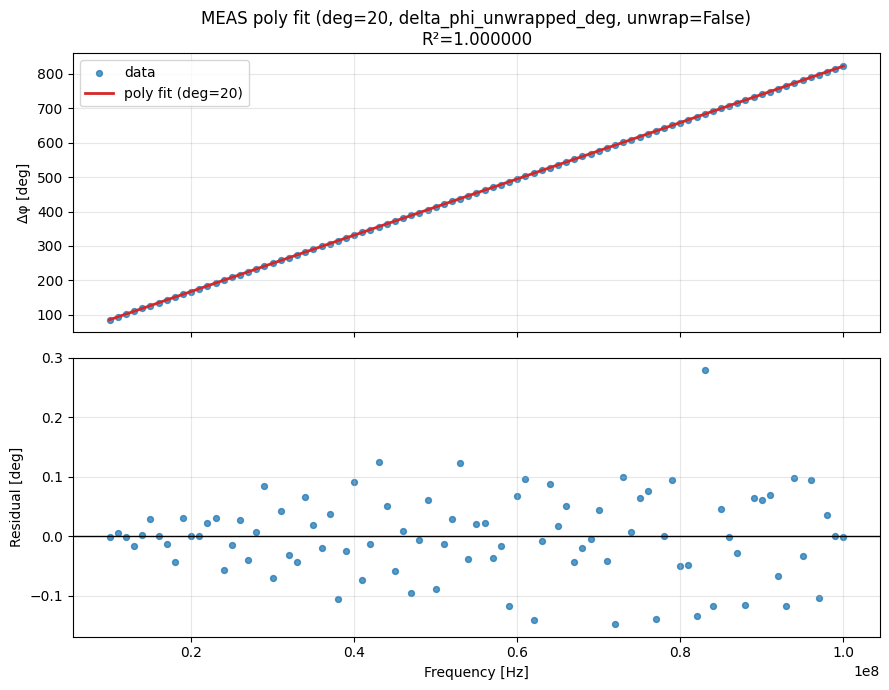


Fit details:
 degree = 20
 normalized = True  (x = (f - f_ref)/f_scale)
 f_ref   = 5.500000e+07 Hz
 f_scale = 4.500000e+07 Hz

Coefficients p (highest power first) for phi(x) = polyval(p, x):
  x^20: 5.658346e+03 ± 6.778e+03  [deg]
  x^19: 4.474682e+03 ± 3.337e+03  [deg]
  x^18: -2.734140e+04 ± 3.329e+04  [deg]
  x^17: -2.179056e+04 ± 1.557e+04  [deg]
  x^16: 5.605598e+04 ± 6.957e+04  [deg]
  ...
  x^ 4: 1.779277e+01 ± 8.934e+01  [deg]
  x^ 3: 4.483552e+01 ± 1.617e+01  [deg]
  x^ 2: -1.330513e-01 ± 3.207e+00  [deg]
  x^ 1: 3.655622e+02 ± 3.598e-01  [deg]
  x^ 0: 4.538239e+02 ± 3.126e-02  [deg]


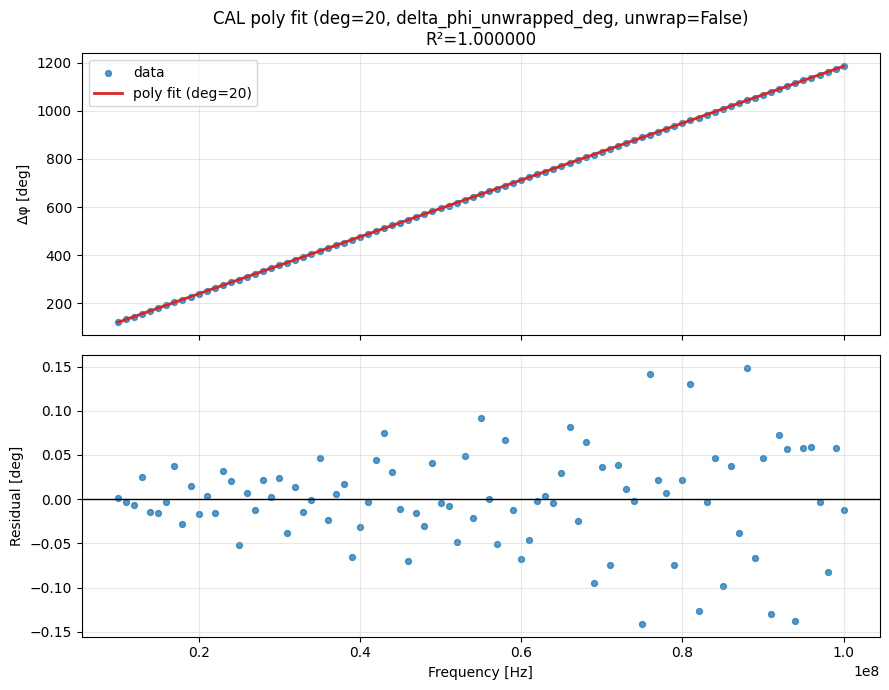


Fit details:
 degree = 20
 normalized = True  (x = (f - f_ref)/f_scale)
 f_ref   = 5.500000e+07 Hz
 f_scale = 4.500000e+07 Hz

Coefficients p (highest power first) for phi(x) = polyval(p, x):
  x^20: -2.440959e+03 ± 5.322e+03  [deg]
  x^19: 2.723449e+03 ± 2.621e+03  [deg]
  x^18: 1.214173e+04 ± 2.614e+04  [deg]
  x^17: -1.408522e+04 ± 1.223e+04  [deg]
  x^16: -2.534875e+04 ± 5.462e+04  [deg]
  ...
  x^ 4: -1.043066e+01 ± 7.015e+01  [deg]
  x^ 3: 4.351724e+01 ± 1.269e+01  [deg]
  x^ 2: -2.869962e+00 ± 2.518e+00  [deg]
  x^ 1: 5.295544e+02 ± 2.825e-01  [deg]
  x^ 0: 6.532388e+02 ± 2.455e-02  [deg]

FIBRE-ONLY coefficients (MEAS - CAL):
 degree = 20
 normalized = True
 f_ref   = 5.500000e+07 Hz
 f_scale = 4.500000e+07 Hz


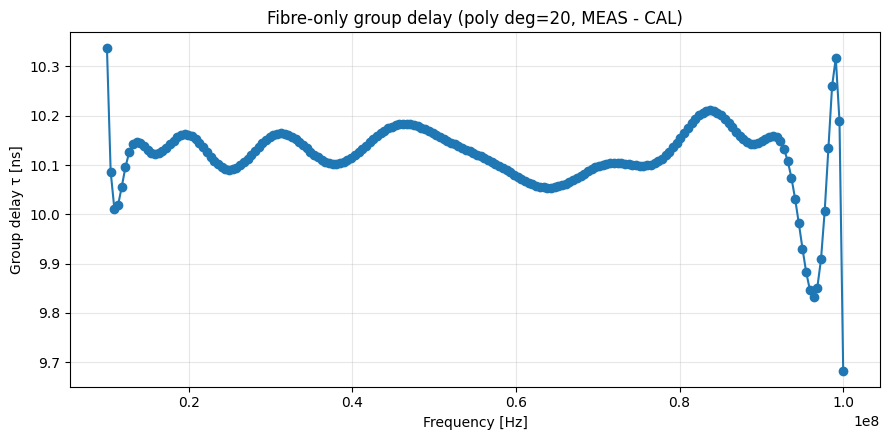


Mid-band frequency f0 = 55.000 MHz
Fibre-only group delay τ(f0) = 10.123 ± 0.028 ns (1σ)
Estimated fibre length L = 2.067 ± 0.0058 m (1σ; sign indicates channel direction)


In [20]:
# ---------- USER SETTINGS ----------
MEAS_CSV = r"C:\Users\Experiment\Documents\Python\VQ_Instruments\calib.csv"
CAL_CSV  = r"C:\Users\Experiment\Documents\Python\VQ_Instruments\fut.csv"

FREQ_COL  = "frequency_hz"
PHASE_COL = None     # auto-detect

UNWRAP = False       # set True if using wrapped phase column
NG = 1.468           # SMF-28 @ 1550 nm

DEG = 20           # <<<<<< 20th-degree polynomial fit
NORMALIZE = True     # strongly recommended for DEG=20


# ---------- LOAD ----------
f_meas, phi_meas, phcol_meas = load_csv(MEAS_CSV, FREQ_COL, PHASE_COL)
f_cal,  phi_cal,  phcol_cal  = load_csv(CAL_CSV,  FREQ_COL, PHASE_COL)

# Compute common normalization based on overlapping band (important for subtraction)
if NORMALIZE:
    f_ref, f_scale, f_overlap_min, f_overlap_max = _compute_common_normalization(f_meas, f_cal)
else:
    f_ref, f_scale = 0.0, 1.0
    f_overlap_min = max(np.min(f_meas), np.min(f_cal))
    f_overlap_max = min(np.max(f_meas), np.max(f_cal))

# ---------- FIT POLYNOMIAL ----------
fit_meas = poly_fit_phase(
    f_meas, phi_meas,
    deg=DEG, unwrap=UNWRAP,
    normalize=NORMALIZE,
    f_ref=f_ref, f_scale=f_scale
)
fit_cal = poly_fit_phase(
    f_cal, phi_cal,
    deg=DEG, unwrap=UNWRAP,
    normalize=NORMALIZE,
    f_ref=f_ref, f_scale=f_scale
)

plot_fit_and_residuals(
    fit_meas,
    title=f"MEAS poly fit (deg={DEG}, {phcol_meas}, unwrap={UNWRAP})"
)
plot_fit_and_residuals(
    fit_cal,
    title=f"CAL poly fit (deg={DEG}, {phcol_cal}, unwrap={UNWRAP})"
)

# ---------- CAL SUBTRACTION ON COEFFS ----------
fit_fibre = poly_calibration_subtract(fit_meas, fit_cal)

print("\nFIBRE-ONLY coefficients (MEAS - CAL):")
print(f" degree = {fit_fibre['deg']}")
print(f" normalized = {fit_fibre['normalized']}")
if fit_fibre["normalized"]:
    print(f" f_ref   = {fit_fibre['f_ref']:.6e} Hz")
    print(f" f_scale = {fit_fibre['f_scale']:.6e} Hz")

# ---------- GROUP DELAY vs F ----------
# Use the overlapping frequency band for plotting
f_common = np.linspace(f_overlap_min, f_overlap_max, 200)

tau_fibre = group_delay_from_poly(
    fit_fibre["p"], f_common,
    normalized=fit_fibre["normalized"],
    f_ref=fit_fibre["f_ref"],
    f_scale=fit_fibre["f_scale"]
)

plot_group_delay(
    f_common, tau_fibre,
    title=f"Fibre-only group delay (poly deg={DEG}, MEAS - CAL)"
)

# ---------- LENGTH at mid-band (with uncertainty) ----------
f0 = 0.5 * (f_common.min() + f_common.max())

# If you have an estimate for ng uncertainty, set SIGMA_NG accordingly.
# Otherwise keep 0 to ignore it.
SIGMA_NG = 0.0

L_m, sL_m, tau0, stau0 = fibre_length_with_uncertainty(
    fit_fibre, f0_hz=f0, ng=NG, sigma_ng=SIGMA_NG
)

print(f"\nMid-band frequency f0 = {f0/1e6:.3f} MHz")
print(f"Fibre-only group delay τ(f0) = {tau0*1e9:.3f} ± {stau0*1e9:.3f} ns (1σ)")
print(f"Estimated fibre length L = {abs(L_m):.3f} ± {sL_m:.4f} m (1σ; sign indicates channel direction)")


In [ ]:
client.close()